In [7]:
import numpy as np
import pandas as pd

def load_and_prep(path="/Users/jerryli/Desktop/MCM/sim_results_v5/sim_summary.csv"):
    df = pd.read_csv(path).copy()
    df = df.sort_values(["scheme", "archetype", "week"])
    eps = 1e-12

    # cumulative survival: S(t)=prod alive_rate
    df["cum_alive_rate"] = (
        df.groupby(["scheme", "archetype"])["alive_rate"]
          .apply(lambda s: np.exp(np.log(s.clip(eps, 1.0)).cumsum()))
          .reset_index(level=[0,1], drop=True)
    )

    # (optional) add week=0 baseline so survival starts at 1
    base = df[["scheme","archetype"]].drop_duplicates()
    base["week"] = 0
    base["cum_alive_rate"] = 1.0
    base["avg_rank"] = np.nan
    base["elim_rate"] = np.nan

    df2 = pd.concat([df, base], ignore_index=True).sort_values(["scheme","archetype","week"])
    return df2

df = load_and_prep("/Users/jerryli/Desktop/MCM/sim_results_v5/sim_summary.csv")


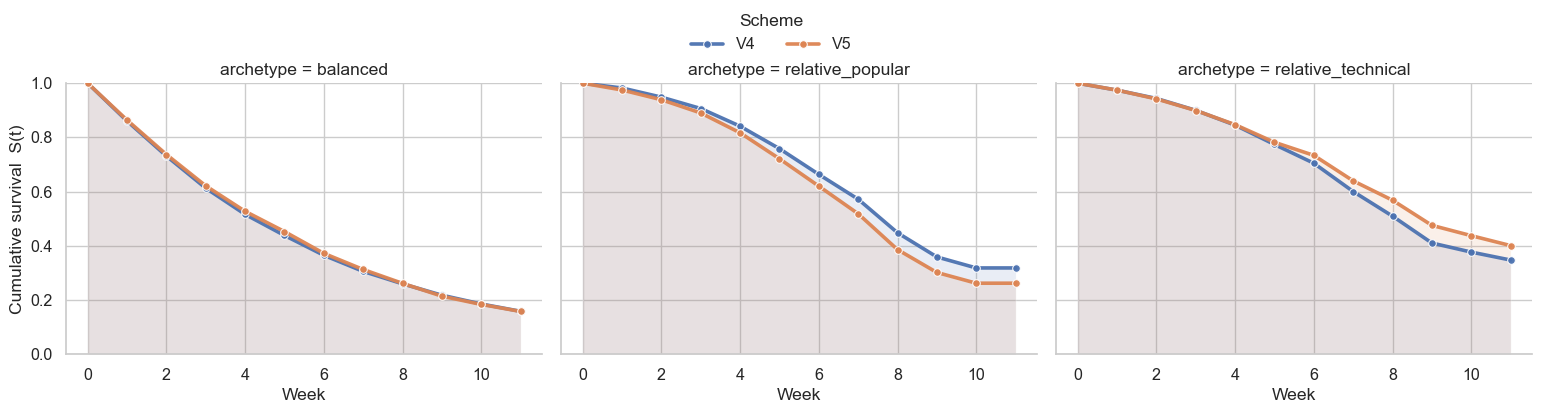

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.05)

metric = "cum_alive_rate"  # 也可以换成 "elim_rate" 或 "avg_rank"
y_label = "Cumulative survival  S(t)"

archetypes = sorted(df["archetype"].unique())
scheme_order = sorted(df["scheme"].unique())

fig, axes = plt.subplots(1, len(archetypes), figsize=(5.2*len(archetypes), 4.2), sharey=True, sharex=True)

if len(archetypes) == 1:
    axes = [axes]

for ax, arch in zip(axes, archetypes):
    sub = df[df["archetype"] == arch].copy()

    # 先画线 + 点
    sns.lineplot(
        data=sub, x="week", y=metric,
        hue="scheme", hue_order=scheme_order,
        marker="o", linewidth=2.6, markersize=5.5,
        alpha=0.95, ax=ax
    )

    # 再补“面”：逐 scheme fill_between（seaborn 没有内置 ribbon，这里用 matplotlib）
    for sch in scheme_order:
        g = sub[sub["scheme"] == sch].dropna(subset=[metric]).sort_values("week")
        ax.fill_between(g["week"].to_numpy(), g[metric].to_numpy(), 0, alpha=0.12)

    ax.set_title(f"archetype = {arch}")
    ax.set_xlabel("Week")
    ax.set_ylabel(y_label)
    ax.set_ylim(0, 1)

    # 美观：去掉上/右边框
    sns.despine(ax=ax)

# legend 放到图外
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg: leg.remove()

fig.legend(handles, labels, title="Scheme", loc="upper center", ncol=len(scheme_order), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig("fig_ribbon_survival_by_archetype.png", dpi=300, bbox_inches="tight")
plt.show()


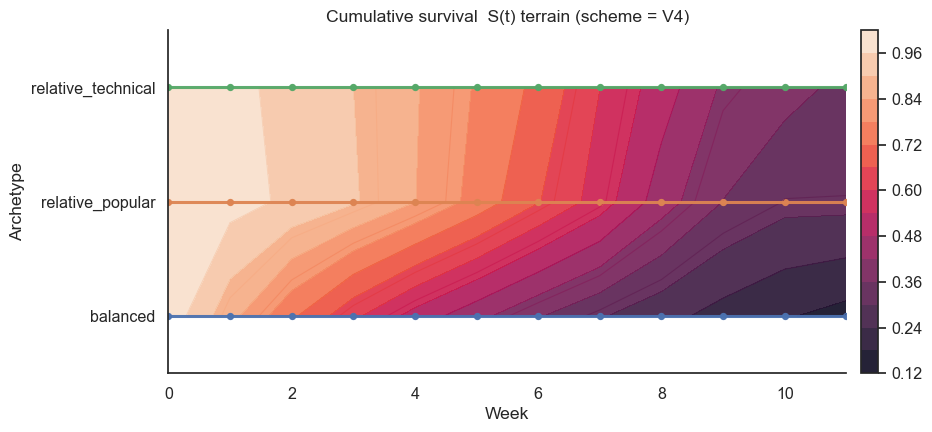

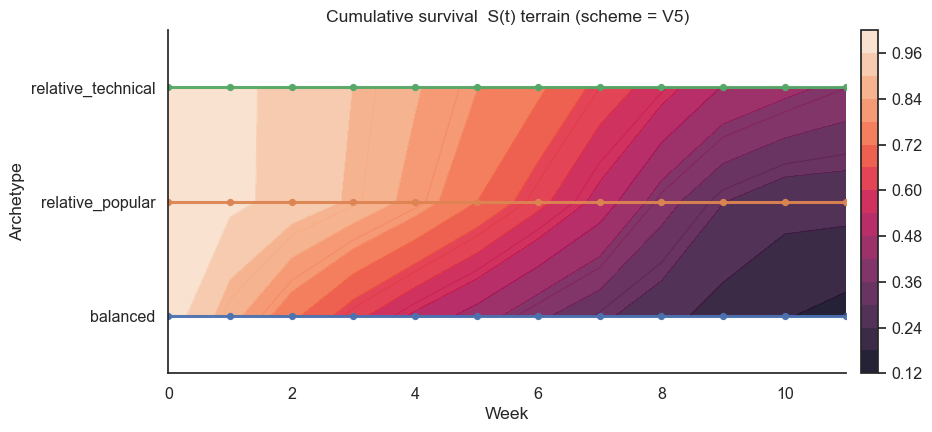

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", font_scale=1.05)

metric = "cum_alive_rate"
title_metric = "Cumulative survival  S(t)"
archetypes = sorted(df["archetype"].unique())
arch2y = {a:i for i,a in enumerate(archetypes)}  # archetype -> y index

scheme_order = sorted(df["scheme"].unique())

# 为每个 scheme 单独画一张“地形图”（更清晰）
for sch in scheme_order:
    sub = df[(df["scheme"] == sch)].dropna(subset=[metric]).copy()
    sub["arch_y"] = sub["archetype"].map(arch2y)

    # grid: X=week, Y=arch_y, Z=metric
    Z = sub.pivot_table(index="arch_y", columns="week", values=metric, aggfunc="mean").sort_index()
    weeks = Z.columns.to_numpy()
    ys = Z.index.to_numpy()
    X, Y = np.meshgrid(weeks, ys)
    Zm = Z.to_numpy()

    fig, ax = plt.subplots(figsize=(9.5, 4.5))

    # 等高线“面”
    cf = ax.contourf(X, Y, Zm, levels=14, alpha=0.90)
    # 边界等高线（立体感更强）
    ax.contour(X, Y, Zm, levels=10, linewidths=0.8, alpha=0.70)

    # 叠加：每个 archetype 的“点+线”轨迹（同一个 scheme 内）
    for a in archetypes:
        g = sub[sub["archetype"] == a].sort_values("week")
        ax.plot(g["week"], g["arch_y"], linewidth=2.2, alpha=0.95)
        ax.scatter(g["week"], g["arch_y"], s=18, alpha=0.95)

    ax.set_title(f"{title_metric} terrain (scheme = {sch})")
    ax.set_xlabel("Week")
    ax.set_ylabel("Archetype")
    ax.set_yticks(list(arch2y.values()))
    ax.set_yticklabels(list(arch2y.keys()))
    ax.set_ylim(-0.5, len(archetypes)-0.5)
    plt.colorbar(cf, ax=ax, fraction=0.05, pad=0.02)

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f"fig_contour_{metric}_{sch}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def contour_by_scheme_rank(path="sim_summary.csv"):
    df = pd.read_csv(path).copy()
    df = df.sort_values(["scheme", "archetype", "week"]).copy()

    # --- map archetype to y index (categorical axis) ---
    archetypes = sorted(df["archetype"].dropna().unique().tolist())
    arch2y = {a: i for i, a in enumerate(archetypes)}
    df["arch_y"] = df["archetype"].map(arch2y)

    # --- transform avg_rank so "higher = better" for terrain intuition ---
    # rank_score = -avg_rank : higher means lower rank (better)
    df["rank_score"] = -df["avg_rank"]

    sns.set_theme(style="white", font_scale=1.05)

    scheme_order = sorted(df["scheme"].dropna().unique().tolist())

    for sch in scheme_order:
        sub = df[(df["scheme"] == sch)].dropna(subset=["rank_score"]).copy()
        if sub.empty:
            continue

        # grid: Y=arch_y, X=week, Z=rank_score
        Z = (
            sub.pivot_table(index="arch_y", columns="week", values="rank_score", aggfunc="mean")
               .sort_index()
        )

        weeks = Z.columns.to_numpy()
        ys = Z.index.to_numpy()
        X, Y = np.meshgrid(weeks, ys)
        Zm = Z.to_numpy()

        fig, ax = plt.subplots(figsize=(9.6, 4.6))

        # Filled contours ("terrain") + contour lines for depth
        cf = ax.contourf(X, Y, Zm, levels=14, alpha=0.92)
        ax.contour(X, Y, Zm, levels=10, linewidths=0.8, alpha=0.75)

        # Overlay: for each archetype, plot the time-trajectory (line + points)
        for a in archetypes:
            g = sub[sub["archetype"] == a].sort_values("week")
            if g.empty:
                continue
            ax.plot(g["week"], g["arch_y"], linewidth=2.2, alpha=0.95)
            ax.scatter(g["week"], g["arch_y"], s=18, alpha=0.95)

        ax.set_title(f"Average Rank Terrain (higher = better; scheme = {sch})")
        ax.set_xlabel("Week")
        ax.set_ylabel("Archetype")
        ax.set_yticks(list(arch2y.values()))
        ax.set_yticklabels(list(arch2y.keys()))
        ax.set_ylim(-0.5, len(archetypes) - 0.5)

        # Colorbar: label back in rank terms (lower is better)
        cbar = plt.colorbar(cf, ax=ax, fraction=0.05, pad=0.02)
        cbar.set_label("Rank score = - avg_rank  (higher = better)")

        sns.despine(ax=ax)
        plt.tight_layout()
        out = f"fig_contour_avg_rank_{sch}.png"
        plt.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()

# run
contour_by_scheme_rank("/Users/jerryli/Desktop/MCM/sim_results_v5/sim_summary.csv")


KeyError: 'avg_rank'

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def diff_contour_rank(path="sim_summary.csv", scheme_base="S1", scheme_new="S3"):
    df = pd.read_csv(path).copy()
    df = df.sort_values(["scheme", "archetype", "week"]).copy()

    # ---- rank_score: higher is better ----
    df["rank_score"] = -df["avg_rank"]

    # keep only the two schemes
    df = df[df["scheme"].isin([scheme_base, scheme_new])].copy()

    # pivot to align weeks/archetypes
    wide = df.pivot_table(
        index=["archetype", "week"],
        columns="scheme",
        values="rank_score",
        aggfunc="mean"
    ).reset_index()

    # diff: new - base (positive => new better)
    wide["diff_rank_score"] = wide[scheme_new] - wide[scheme_base]

    # map archetype to y index
    archetypes = sorted(wide["archetype"].dropna().unique().tolist())
    arch2y = {a: i for i, a in enumerate(archetypes)}
    wide["arch_y"] = wide["archetype"].map(arch2y)

    # grid for contour
    Z = (wide.pivot_table(index="arch_y", columns="week", values="diff_rank_score", aggfunc="mean")
              .sort_index())
    weeks = Z.columns.to_numpy()
    ys = Z.index.to_numpy()
    X, Y = np.meshgrid(weeks, ys)
    Zm = Z.to_numpy()

    # choose symmetric color limits around 0 (so red/blue meaning stable)
    vmax = np.nanmax(np.abs(Zm))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    sns.set_theme(style="white", font_scale=1.05)
    fig, ax = plt.subplots(figsize=(10.2, 4.8))

    # filled contour (diverging) + lines
    cf = ax.contourf(X, Y, Zm, levels=15, vmin=-vmax, vmax=vmax, alpha=0.93)
    ax.contour(X, Y, Zm, levels=10, linewidths=0.8, alpha=0.65)
    # emphasize zero boundary
    ax.contour(X, Y, Zm, levels=[0], linewidths=2.2, alpha=0.95)

    # overlay points/lines for each archetype (diff trajectory)
    for a in archetypes:
        g = wide[wide["archetype"] == a].sort_values("week")
        ax.plot(g["week"], g["arch_y"], linewidth=2.2, alpha=0.95)
        ax.scatter(g["week"], g["arch_y"], s=18, alpha=0.95)

    ax.set_title(f"Δ Average Rank (better if positive): {scheme_new} vs {scheme_base}")
    ax.set_xlabel("Week")
    ax.set_ylabel("Archetype")
    ax.set_yticks(list(arch2y.values()))
    ax.set_yticklabels(list(arch2y.keys()))
    ax.set_ylim(-0.5, len(archetypes) - 0.5)

    cbar = plt.colorbar(cf, ax=ax, fraction=0.05, pad=0.02)
    cbar.set_label(f"Δ rank_score = (-avg_rank_{scheme_new}) - (-avg_rank_{scheme_base})\n(>0 => {scheme_new} improves rank)")

    sns.despine(ax=ax)
    plt.tight_layout()
    out = f"fig_diff_contour_avg_rank_{scheme_new}_minus_{scheme_base}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

# run
diff_contour_rank("/Users/jerryli/Desktop/MCM/sim_results_v5/sim_summary.csv", scheme_base="S1", scheme_new="S3")


KeyError: 'avg_rank'